# SpiderNet transfer-data preprocessing tutorial (AgingBrain Sagittal + Hippocampus)

This notebook prepares processed SpiderNet bundles for the **sagittal** and **hippocampus** transfer datasets used by `AgingBrain_transfer_Sagittal_Hippocampus_analysis_updated`.

It follows the unified `dataloading_unified` workflow, while preserving the important dataset-specific behavior from the original loaders:
- **Sagittal** keeps age-based batching, `center_x`/`center_y` spatial coordinates, and the same HVG-based preprocessing logic.
- **Hippocampus** reuses the **training gene list**, reads counts from `layers["raw_count"]`, and harmonizes hippocampus-specific cell-type labels before building the processed bundle.

In [1]:
from pathlib import Path
import pickle
import sys

import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

sys.path.append(str(Path.cwd()))

from SpiderNet.dataloading_unified import (
    prepare_processed_bundle_unified,
    preview_lr_corr_distribution,
)
from SpiderNet.utils import (
    get_default_cellchat_db,
    get_default_scseqcomm_db,
)


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Step 1. Basic user inputs

Edit these paths and preprocessing settings first.

In [2]:
TRAIN_PROCESSED_DATA_DIR = Path("D:/SpiderNet/Results/AgingBrain/ProcessedData")

SAGITTAL_DATA_ROOT = Path("D:/SpiderNet/Data/AgingBrain/AgingBrain_Sagittal")
SAGITTAL_OUTPUT_DIR = Path("D:/SpiderNet/Results/AgingBrain/AgingBrain_Sagittal/ProcessedData")

HIPPOCAMPUS_DATA_ROOT = Path("D:/SpiderNet/Data/AgingBrain/AgingBrain_Hippocampus")
HIPPOCAMPUS_OUTPUT_DIR = Path("D:/SpiderNet/Results/AgingBrain/AgingBrain_Hippocampus/ProcessedData")

SPECIES = "mouse"

# Keep these aligned with the transfer-analysis notebook unless you have a strong reason to change them.
N_HVG = 1000
N_HVG_LR = 2000
NUM_NEIGHBORS = 5

# The original sagittal and hippocampus loaders both filtered LR pairs using a fixed correlation cutoff of 0.3.
# You can inspect the preview plots below before changing these values.
SAGITTAL_LR_CORR_THRESHOLD = 0.3
HIPPOCAMPUS_LR_CORR_THRESHOLD = 0.3

SHOW_PREVIEW_PLOTS = True


## Step 2. Dataset-specific preprocessing rules

This section encodes the sagittal- and hippocampus-specific behavior that used to live in `dataloading_AgingMousebrain` and `dataloading_AgingMouseHippocampus`.

In [3]:
CELLCHAT_DB = get_default_cellchat_db(species=SPECIES)
SCSEQCOMM_DB = get_default_scseqcomm_db(species=SPECIES)

HIPPOCAMPUS_CELLTYPE_MAPPING = {
    "Astro-1": "Astrocyte",
    "Astro-2": "Astrocyte",
    "NPC-DG": "NSC",
    "Neuron-CA1": "Neuron-Excitatory",
    "Neuron-CA2&3": "Neuron-Excitatory",
    "OL-WM": "Oligodendrocyte",
}


def load_training_gene_list_path() -> Path:
    gene_list_path = TRAIN_PROCESSED_DATA_DIR / "genenames_train.pkl"
    if not gene_list_path.exists():
        raise FileNotFoundError(
            f"Training gene list was not found: {gene_list_path}. Run the training-data preprocessing notebook first."
        )
    return gene_list_path


def load_sagittal_gene_list_path(require_exists: bool = False) -> Path:
    gene_list_path = SAGITTAL_OUTPUT_DIR / "genenames_train.pkl"
    if require_exists and not gene_list_path.exists():
        raise FileNotFoundError(
            f"Sagittal gene list was not found: {gene_list_path}. Run the sagittal bundle cell first."
        )
    return gene_list_path


def extract_age_from_filename(file_name: str) -> float:
    stem = Path(file_name).stem
    if "_age" not in stem:
        raise ValueError(
            f"Cannot parse age from file name: {file_name}. Expected a pattern like '*_age12.h5ad'."
        )
    return float(stem.split("_age", 1)[1])


def sagittal_file_sort_key(file_name: str):
    return extract_age_from_filename(file_name)


def hippocampus_per_file_hook(adata: sc.AnnData, context: dict) -> sc.AnnData:
    adata = adata.copy()
    file_stem = Path(context["file_name"]).stem

    if "celltype" not in adata.obs.columns:
        if "cell_type" not in adata.obs.columns:
            raise KeyError(
                "Expected either 'celltype' or 'cell_type' in hippocampus AnnData.obs."
            )
        adata.obs["celltype"] = (
            adata.obs["cell_type"]
            .map(HIPPOCAMPUS_CELLTYPE_MAPPING)
            .fillna(adata.obs["cell_type"])
        )

    adata.obs["sample_name_full"] = file_stem
    return adata


def build_sagittal_config() -> dict:
    return {
        "data_path_main": SAGITTAL_DATA_ROOT,
        "output_dir": SAGITTAL_OUTPUT_DIR,
        "ligand_receptor_filedir_cellchatdb": CELLCHAT_DB,
        "ligand_receptor_filedir_scSeqComm": SCSEQCOMM_DB,
        "sample_col": "age",
        "cell_class_col": "celltype",
        "pyg_obs_fields": {
            "age": "age",
            "batch": "age",
            "region": "region",
            "subregion": "subregion",
        },
        "file_sort_key": sagittal_file_sort_key,
        "expression_source": {"kind": "X", "name": None},
        "spatial_source": {"kind": "obs", "cols": ["center_x", "center_y"]},
        "normalize_strategy": "always",
        "n_hvg": N_HVG,
        "n_hvg_lr": N_HVG_LR,
        "num_neighbors": NUM_NEIGHBORS,
        "lr_corr_threshold": SAGITTAL_LR_CORR_THRESHOLD,
    }


def build_hippocampus_config() -> dict:
    sagittal_gene_list_path = load_sagittal_gene_list_path(require_exists=True)
    return {
        "data_path_main": HIPPOCAMPUS_DATA_ROOT,
        "output_dir": HIPPOCAMPUS_OUTPUT_DIR,
        "ligand_receptor_filedir_cellchatdb": CELLCHAT_DB,
        "ligand_receptor_filedir_scSeqComm": SCSEQCOMM_DB,
        "sample_col": "sample_name_full",
        "sample_name_obs_col": "sample_name_full",
        "sample_attr_obs_col": "sample_name_full",
        "sample_sort": "lexicographic",
        "cell_class_col": "celltype",
        "per_file_hook": hippocampus_per_file_hook,
        "expression_source": {"kind": "layer", "name": "raw_count"},
        "spatial_source": {"kind": "obsm", "key": "spatial"},
        "gene_list_path": str(sagittal_gene_list_path),
        "fill_missing_requested_genes": True,
        "requested_gene_fill_value": 0.0,
        "apply_hvg_selection": False,
        "normalize_strategy": "always",
        "n_hvg": N_HVG,
        "n_hvg_lr": N_HVG_LR,
        "num_neighbors": NUM_NEIGHBORS,
        "lr_corr_threshold": HIPPOCAMPUS_LR_CORR_THRESHOLD,
    }


## Step 3. Quick path check

In [4]:
rows = [
    {"item": "TRAIN_PROCESSED_DATA_DIR", "value": str(TRAIN_PROCESSED_DATA_DIR), "exists": TRAIN_PROCESSED_DATA_DIR.exists()},
    {"item": "SAGITTAL_DATA_ROOT", "value": str(SAGITTAL_DATA_ROOT), "exists": SAGITTAL_DATA_ROOT.exists()},
    {"item": "SAGITTAL_OUTPUT_DIR", "value": str(SAGITTAL_OUTPUT_DIR), "exists": SAGITTAL_OUTPUT_DIR.exists()},
    {"item": "Sagittal gene list (after Step 5)", "value": str(load_sagittal_gene_list_path()), "exists": load_sagittal_gene_list_path().exists()},
    {"item": "HIPPOCAMPUS_DATA_ROOT", "value": str(HIPPOCAMPUS_DATA_ROOT), "exists": HIPPOCAMPUS_DATA_ROOT.exists()},
    {"item": "HIPPOCAMPUS_OUTPUT_DIR", "value": str(HIPPOCAMPUS_OUTPUT_DIR), "exists": HIPPOCAMPUS_OUTPUT_DIR.exists()},
    {"item": "CellChat DB", "value": str(CELLCHAT_DB), "exists": Path(CELLCHAT_DB).exists()},
    {"item": "scSeqComm DB", "value": str(SCSEQCOMM_DB), "exists": Path(SCSEQCOMM_DB).exists()},
    {"item": "Training gene list (reference only)", "value": str(load_training_gene_list_path()), "exists": load_training_gene_list_path().exists()},
]
display(pd.DataFrame(rows))

,item,value,exists
0,TRAIN_PROCESSED_DATA_DIR,D:\SpiderNet\Results\AgingBrain\ProcessedData,True
1,SAGITTAL_DATA_ROOT,D:\SpiderNet\Data\AgingBrain\AgingBrain_Sagittal,True
2,SAGITTAL_OUTPUT_DIR,D:\SpiderNet\Results\AgingBrain\AgingBrain_Sag...,True
3,Sagittal gene list (after Step 5),D:\SpiderNet\Results\AgingBrain\AgingBrain_Sag...,True
4,HIPPOCAMPUS_DATA_ROOT,D:\SpiderNet\Data\AgingBrain\AgingBrain_Hippoc...,True
5,HIPPOCAMPUS_OUTPUT_DIR,D:\SpiderNet\Results\AgingBrain\AgingBrain_Hip...,False
6,CellChat DB,D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\...,True
7,scSeqComm DB,D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\...,True
8,Training gene list (reference only),D:\SpiderNet\Results\AgingBrain\ProcessedData\...,True


## Step 4. Optional preview: sagittal LR-correlation distribution

This preview stops before the final saving step. It is useful if you want to adjust `SAGITTAL_LR_CORR_THRESHOLD`.

Preview: load the data and run up to the LR-correlation stage
Reading AnnData files from: D:\SpiderNet\Data\AgingBrain\AgingBrain_Sagittal\adata


D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\dataloading_unified.py:584: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = sc.AnnData.concatenate(*adata_file_list, batch_key="_concat_batch", index_unique=None)


Number of ligand-receptor pairs from CellChatDB: 27
Number of ligand-receptor pairs from scSeqComm: 88
Total number of Ligand–Receptor pairs after concatenating scSeqComm + CellChat without global deduplication: 115


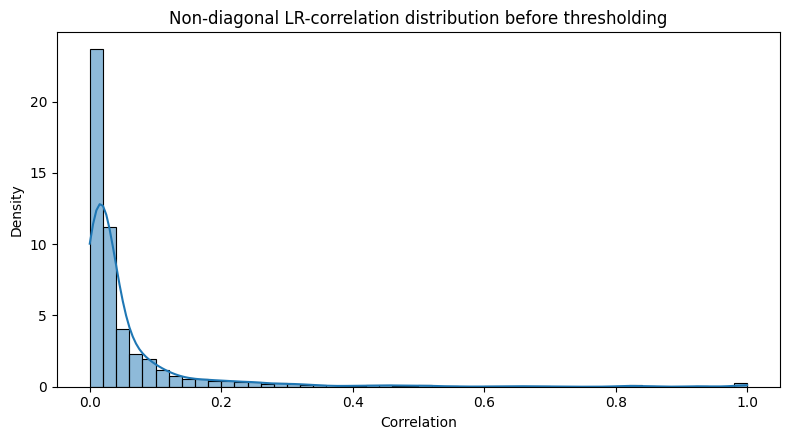

count     8372.000000
mean         0.058925
std          0.120657
min          0.000000
max          1.000000
median       0.021296
q00          0.000000
q01          0.000000
q05          0.000000
q10          0.003629
q25          0.010587
q50          0.021296
q75          0.051320
q90          0.132801
q95          0.245578
q99          0.695429
q100         1.000000
Name: non_diagonal_lr_correlation, dtype: float64

In [5]:
sagittal_preview = preview_lr_corr_distribution(
    build_sagittal_config(),
    preview_output_dir=SAGITTAL_OUTPUT_DIR / "_lr_corr_preview",
    show_plot=SHOW_PREVIEW_PLOTS,
)

sagittal_preview["summary"]


## Step 5. Build the sagittal processed bundle

In [6]:
sagittal_bundle = prepare_processed_bundle_unified(build_sagittal_config())

print("Sagittal output dir:", sagittal_bundle["output_dir"])
print("Sagittal batches:", len(sagittal_bundle["batch_cell_unique"]))
print("Sagittal total cells:", sagittal_bundle["adata"].n_obs)
print("Sagittal training genes:", len(sagittal_bundle["genenames_train"]))
print("Sagittal training LR pairs:", len(sagittal_bundle["LR_list"]))


Step 1: Load the data and perform preprocessing
Reading AnnData files from: D:\SpiderNet\Data\AgingBrain\AgingBrain_Sagittal\adata
AnnData object with n_obs × n_vars = 129656 × 300
    obs: 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'transcript_count', 'num_detected_genes', 'barcodeCount', 'mouse_id', 'slide_id', 'cohort', 'age', 'batch', 'celltype', 'region', 'subregion'
    uns: 'neighbors', 'pca', 'umap', 'log1p'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\dataloading_unified.py:996: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = sc.AnnData.concatenate(*adata_file_list, batch_key="_concat_batch", index_unique=None)


Number of ligand-receptor pairs from CellChatDB: 27
Number of ligand-receptor pairs from scSeqComm: 88
Total number of Ligand–Receptor pairs after concatenating scSeqComm + CellChat without global deduplication: 115
Step 2: Build sample-level SpiderNet data dictionaries
Step 3: Build spatial neighbor graph
Total number of edges across all samples: 4303585
Step 4: One-hot encoding of cell types and PyG object creation
Step 5: Compute cell–cell–LRpair tensor
Step 6: Filter LR pairs based on coverage across edges
Quantiles of LR pair activation proportion: [0.00115536 0.0100162  0.04235207 0.10615289 0.69244462]
Step 7: Compute pairwise LR correlation across samples
Step 8: Finalize PyG features and cell labels
Step 9: Compute neighboring cell-type proportions
Step 11: Build batch-aligned adata_list
Step 12: Save processed objects
Done.
Sagittal output dir: D:\SpiderNet\Results\AgingBrain\AgingBrain_Sagittal\ProcessedData
Sagittal batches: 6
Sagittal total cells: 860717
Sagittal training 

## Step 6. Optional preview: hippocampus LR-correlation distribution

This step uses the **Sagittal processed gene list** generated in Step 5, so run the sagittal bundle cell first.

Using sagittal gene list: D:\SpiderNet\Results\AgingBrain\AgingBrain_Sagittal\ProcessedData\genenames_train.pkl
Preview: load the data and run up to the LR-correlation stage
Reading AnnData files from: D:\SpiderNet\Data\AgingBrain\AgingBrain_Hippocampus\adata


D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\dataloading_unified.py:584: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = sc.AnnData.concatenate(*adata_file_list, batch_key="_concat_batch", index_unique=None)
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not

Number of ligand-receptor pairs from CellChatDB: 23
Number of ligand-receptor pairs from scSeqComm: 73
Total number of Ligand–Receptor pairs after concatenating scSeqComm + CellChat without global deduplication: 96


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


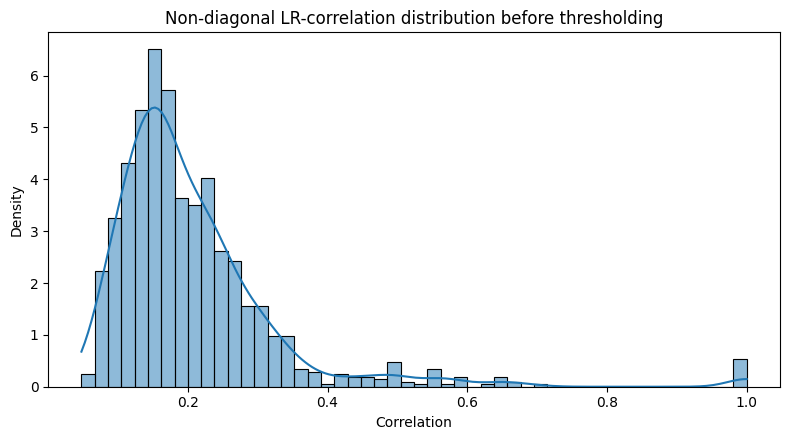

count     2162.000000
mean         0.207934
std          0.127739
min          0.047738
max          1.000000
median       0.173333
q00          0.047738
q01          0.072800
q05          0.086418
q10          0.102115
q25          0.136437
q50          0.173333
q75          0.241216
q90          0.317401
q95          0.429483
q99          0.815915
q100         1.000000
Name: non_diagonal_lr_correlation, dtype: float64

In [7]:
print("Using sagittal gene list:", load_sagittal_gene_list_path(require_exists=True))

hippocampus_preview = preview_lr_corr_distribution(
    build_hippocampus_config(),
    preview_output_dir=HIPPOCAMPUS_OUTPUT_DIR / "_lr_corr_preview",
    show_plot=SHOW_PREVIEW_PLOTS,
)

hippocampus_preview["summary"]

## Step 7. Build the hippocampus processed bundle

The hippocampus bundle is aligned to the Sagittal training-gene space before LR construction.

In [8]:
print("Using sagittal gene list:", load_sagittal_gene_list_path(require_exists=True))

hippocampus_bundle = prepare_processed_bundle_unified(build_hippocampus_config())

print("Hippocampus output dir:", hippocampus_bundle["output_dir"])
print("Hippocampus batches:", len(hippocampus_bundle["batch_cell_unique"]))
print("Hippocampus total cells:", hippocampus_bundle["adata"].n_obs)
print("Hippocampus training genes:", len(hippocampus_bundle["genenames_train"]))
print("Hippocampus training LR pairs:", len(hippocampus_bundle["LR_list"]))

Using sagittal gene list: D:\SpiderNet\Results\AgingBrain\AgingBrain_Sagittal\ProcessedData\genenames_train.pkl
Step 1: Load the data and perform preprocessing
Reading AnnData files from: D:\SpiderNet\Data\AgingBrain\AgingBrain_Hippocampus\adata
AnnData object with n_obs × n_vars = 4298 × 300
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'celltype', 'sample_name_full'
    uns: 'log1p'
    obsm: 'spatial', 'X_pca', 'X_umap'
    layers: 'raw_count'


D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\dataloading_unified.py:996: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = sc.AnnData.concatenate(*adata_file_list, batch_key="_concat_batch", index_unique=None)
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not

Number of ligand-receptor pairs from CellChatDB: 23
Number of ligand-receptor pairs from scSeqComm: 73
Total number of Ligand–Receptor pairs after concatenating scSeqComm + CellChat without global deduplication: 96
Step 2: Build sample-level SpiderNet data dictionaries
Step 3: Build spatial neighbor graph
Total number of edges across all samples: 138120
Step 4: One-hot encoding of cell types and PyG object creation
Step 5: Compute cell–cell–LRpair tensor
Step 6: Filter LR pairs based on coverage across edges
Quantiles of LR pair activation proportion: [0.00000000e+00 3.26317502e-04 9.72545333e-03 4.74639349e-02
 3.32014889e-01]
Step 7: Compute pairwise LR correlation across samples


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Step 8: Finalize PyG features and cell labels
Step 9: Compute neighboring cell-type proportions
Step 11: Build batch-aligned adata_list
Step 12: Save processed objects
Done.
Hippocampus output dir: D:\SpiderNet\Results\AgingBrain\AgingBrain_Hippocampus\ProcessedData
Hippocampus batches: 6
Hippocampus total cells: 27624
Hippocampus training genes: 300
Hippocampus training LR pairs: 44


## Step 8. Final output summary

These are the processed-data directories that the updated transfer-analysis notebook expects.

In [9]:
summary_df = pd.DataFrame([
    {
        "dataset": "Sagittal",
        "processed_dir": str(SAGITTAL_OUTPUT_DIR),
        "exists": SAGITTAL_OUTPUT_DIR.exists(),
        "bundle_summary": str(SAGITTAL_OUTPUT_DIR / "bundle_summary.json"),
        "n_cells": sagittal_bundle["adata"].n_obs,
        "n_genes_train": len(sagittal_bundle["genenames_train"]),
        "n_lr_pairs_train": len(sagittal_bundle["LR_list"]),
    },
    {
        "dataset": "Hippocampus",
        "processed_dir": str(HIPPOCAMPUS_OUTPUT_DIR),
        "exists": HIPPOCAMPUS_OUTPUT_DIR.exists(),
        "bundle_summary": str(HIPPOCAMPUS_OUTPUT_DIR / "bundle_summary.json"),
        "n_cells": hippocampus_bundle["adata"].n_obs,
        "n_genes_train": len(hippocampus_bundle["genenames_train"]),
        "n_lr_pairs_train": len(hippocampus_bundle["LR_list"]),
    },
])

display(summary_df)


,dataset,processed_dir,exists,bundle_summary,n_cells,n_genes_train,n_lr_pairs_train
0,Sagittal,D:\SpiderNet\Results\AgingBrain\AgingBrain_Sag...,True,D:\SpiderNet\Results\AgingBrain\AgingBrain_Sag...,860717,300,80
1,Hippocampus,D:\SpiderNet\Results\AgingBrain\AgingBrain_Hip...,True,D:\SpiderNet\Results\AgingBrain\AgingBrain_Hip...,27624,300,44
